In [19]:
import pandas as pd
import pickle as pk
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/data_clustered.csv')
df = df[df['price']>50000]
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
df.head()

,Unnamed: 0,price,sqft_living,sqft_lot,waterfront,sqft_above,sqft_basement,street,city,year,month,day,zipcode,city_clean,city_encoded,bedrooms,bathrooms,floors,view,condition,yr_built,yr_renovated,log_price,log_sqft_living,log_sqft_lot,log_sqft_above,log_sqft_basement,cluster_id
0,0,313000.0,1340,7912,0,1340,0,18810 Densmore Ave N,Shoreline,2014,5,2,98133,Shoreline,420396.789025,0.0,-1.000000,0.0,0.0,0.0,-0.456522,1.003002,-0.547243,-0.667630,0.037253,-0.259581,0.000000,0
1,1,2384000.0,3650,9050,0,3370,280,709 W Blaine St,Seattle,2014,5,2,98119,Seattle,579837.467282,2.0,0.333333,0.5,4.0,2.0,-1.195652,0.000000,2.323245,1.046138,0.207703,1.140150,0.878920,1
2,2,342000.0,1930,11947,0,1930,0,26206-26214 143rd Ave SE,Kent,2014,5,2,98042,Kent,439492.452325,0.0,-0.333333,-0.5,0.0,1.0,-0.217391,0.000000,-0.421970,-0.043741,0.559961,0.294093,0.000000,0
3,3,420000.0,2000,8030,0,1000,1000,857 170th Pl NE,Bellevue,2014,5,2,98008,Bellevue,847180.662995,0.0,0.000000,-0.5,0.0,1.0,-0.282609,0.000000,-0.131513,0.017188,0.056030,-0.703611,1.076953,0
4,4,550000.0,1940,10500,0,1140,800,9105 170th Ave NE,Redmond,2014,5,2,98052,Redmond,667649.534728,1.0,0.333333,-0.5,0.0,1.0,0.000000,0.996498,0.249738,-0.034903,0.396201,-0.504832,1.042207,2


In [3]:
feature_columns =['log_sqft_living'
, 'log_sqft_lot'
, 'log_sqft_above'
, 'log_sqft_basement'
, 'bedrooms'
, 'bathrooms'
, 'floors'
, 'view'
, 'condition'
,'yr_built'
, 'yr_renovated'
, 'waterfront']

target_column = ['cluster_id']
x = df[feature_columns].copy()
y = df[target_column].copy()
x_train ,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

y_train = y_train.values.ravel()
y_test = y_test.values.ravel()
pipelines = {
    "Logistic Regression Pipeline": Pipeline([
        ('classifier', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "K-Nearest Neighbors Pipeline": Pipeline([
        ('classifier', KNeighborsClassifier(n_neighbors=4))
    ]),
    "Random Forest Pipeline": Pipeline([
        ('classifier', RandomForestClassifier(n_estimators=150, random_state=42))
    ]),
    "Gradient Boosting Pipeline": Pipeline([
        ('classifier', GradientBoostingClassifier(n_estimators=150, random_state=42))
    ])
}
pipeline_metrics = []

for pipe_name, pipe_obj in pipelines.items():
    pipe_obj.fit(x_train, y_train)

    y_pred = pipe_obj.predict(x_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    pipeline_metrics.append({
        "Pipeline Architecture": pipe_name,
        "Accuracy": round(acc, 4),
        "F1-Score": round(f1, 4)
    })
df_pipe_comparison = pd.DataFrame(pipeline_metrics).sort_values(by="Accuracy", ascending=False)
print(df_pipe_comparison.to_string(index=False))

       Pipeline Architecture  Accuracy  F1-Score
Logistic Regression Pipeline    0.9934    0.9934
  Gradient Boosting Pipeline    0.9641    0.9641
      Random Forest Pipeline    0.9480    0.9479
K-Nearest Neighbors Pipeline    0.9436    0.9434


In [4]:
winning_model = pipelines['Logistic Regression Pipeline']
y_pred = winning_model.predict(x_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       585
           1       0.99      0.98      0.99       263
           2       0.99      0.99      0.99       517

    accuracy                           0.99      1365
   macro avg       0.99      0.99      0.99      1365
weighted avg       0.99      0.99      0.99      1365



In [15]:
regression_features = [
    'log_sqft_living', 'log_sqft_lot', 'log_sqft_above', 'log_sqft_basement',
    'bedrooms', 'bathrooms', 'floors', 'view', 'condition',
    'yr_built', 'yr_renovated', 'waterfront', 'cluster_id'
]

X_reg = df[regression_features].copy()
X_reg = pd.get_dummies(X_reg, columns=['cluster_id'], drop_first=True)

y_reg = np.log(df['price']).copy().values
y_raw_price = df['price'].copy().values

X_train, X_test, y_train, y_test, price_train, price_test = train_test_split(
    X_reg, y_reg, y_raw_price, test_size=0.2, random_state=42
)

reg_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
reg_model.fit(X_train, y_train)

y_pred_log = reg_model.predict(X_test)
y_pred_dollars = np.exp(y_pred_log)

r2 = r2_score(y_test, y_pred_log)
mae_dollars = mean_absolute_error(price_test, y_pred_dollars)

print("--- ALIGNED REGRESSION EVALUATION (LOG1P) ---")
print(f"Fixed R-squared (R²) Score: {r2:.4f}")
print(f"True Average Prediction Error: ${mae_dollars:,.2f}")

--- ALIGNED REGRESSION EVALUATION (LOG1P) ---
Fixed R-squared (R²) Score: 0.5424
True Average Prediction Error: $167,192.82


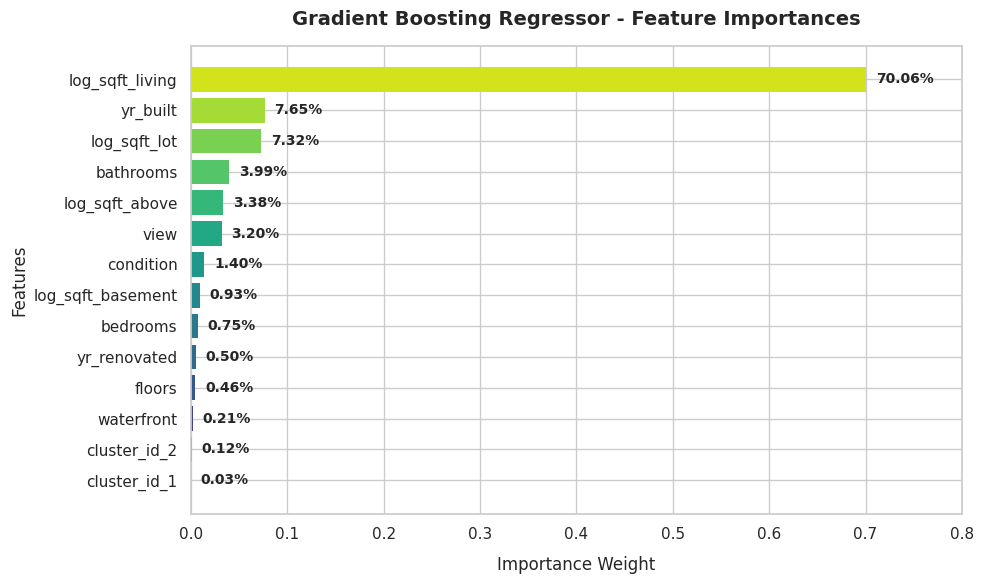

In [24]:
importances = reg_model.feature_importances_
feature_names = X_reg.columns

df_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
colors = sns.color_palette("viridis", len(df_imp))

bars = plt.barh(df_imp['Feature'], df_imp['Importance'], color=colors, edgecolor='none')
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.01,
        bar.get_y() + bar.get_height()/2,
        f'{width*100:.2f}%',
        va='center',
        ha='left',
        fontsize=10,
        weight='bold'
    )

plt.title('Gradient Boosting Regressor - Feature Importances', fontsize=14, weight='bold', pad=15)
plt.xlabel('Importance Weight', fontsize=12, labelpad=10)
plt.ylabel('Features', fontsize=12)
plt.xlim(0, 0.8)
plt.tight_layout()

plt.savefig('feature_importance_analysis.png', dpi=300)
plt.show()